# Customer Churn Prediction and Customer Segmentation using Machine Learning

### Submitted By:
Abhishek Das

### Objective
This project aims to analyze customer data, segment customers into meaningful groups using K-Means clustering, and predict customer churn using machine learning classification algorithms.

In [141]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [142]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (3).csv


## 1. Dataset Overview

The IBM Telco Customer Churn dataset contains customer demographic information, subscribed services, account details, and whether the customer has churned. The objective is to analyze customer behavior, segment customers into groups, and predict whether a customer is likely to leave the company.

In [143]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [144]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Statistical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Missing Values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [145]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [146]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [147]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


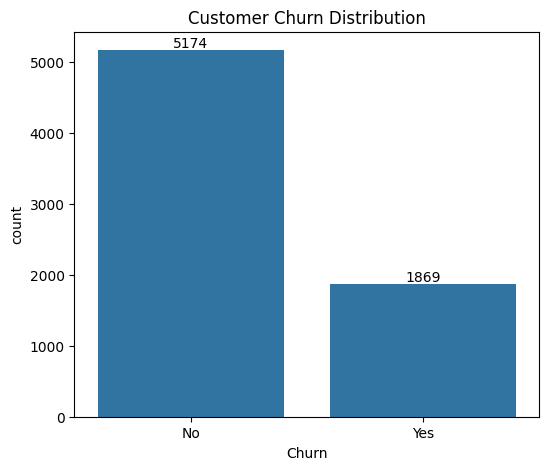

In [148]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x="Churn", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.show()

### Observation

Most customers did not churn, while a smaller proportion left the company. This indicates that the dataset is moderately imbalanced and churn prediction should account for this during model evaluation.

# 2. Data Cleaning & Preprocessing

In this section, we prepare the dataset for machine learning by:
- Checking for incorrect data types
- Handling missing values
- Removing unnecessary columns
- Encoding categorical variables
- Scaling numerical features (later)

In [149]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [151]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [152]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [153]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [154]:
df.drop("customerID", axis=1, inplace=True)

In [155]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the distribution of data, identify patterns, detect outliers, and discover relationships between different customer attributes and churn.

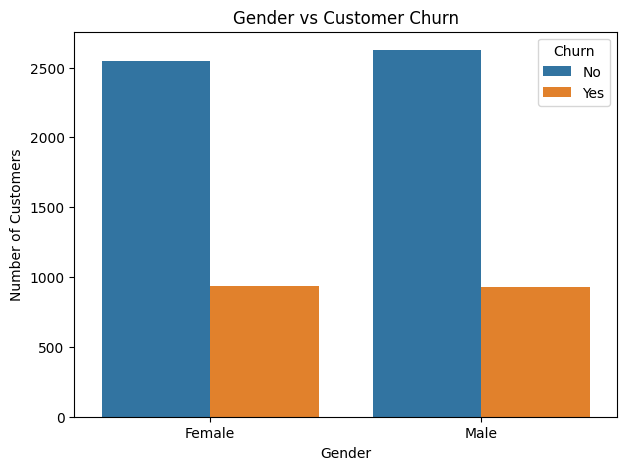

In [156]:
plt.figure(figsize=(7,5))
sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Both male and female customers show similar churn behavior. Gender does not appear to have a significant impact on customer churn.

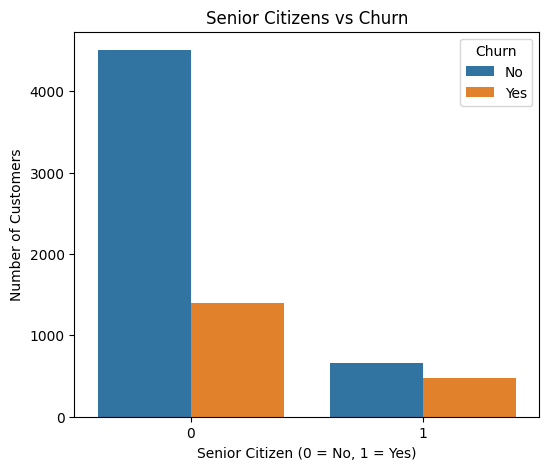

In [157]:
plt.figure(figsize=(6,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizens vs Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

### Observation
Senior citizens have a relatively higher churn rate compared to non-senior customers.

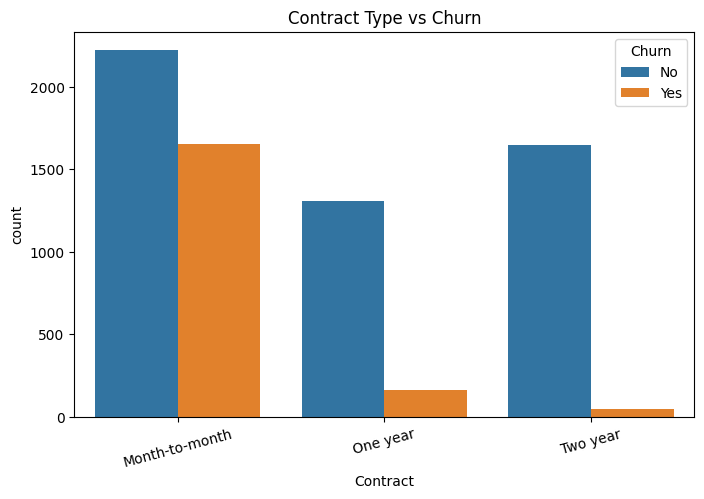

In [158]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)

plt.show()

### Observation

Customers with month-to-month contracts have the highest churn rate, whereas customers with one-year and two-year contracts are more likely to stay.

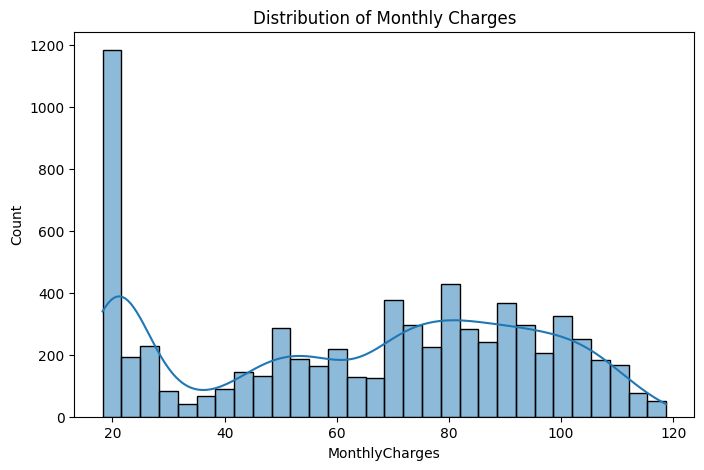

In [159]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

### Observation
Monthly charges vary widely across customers, indicating different service plans and pricing levels.

### Business Insights
Customers paying higher monthly charges may require additional value-added services to reduce the likelihood of churn.

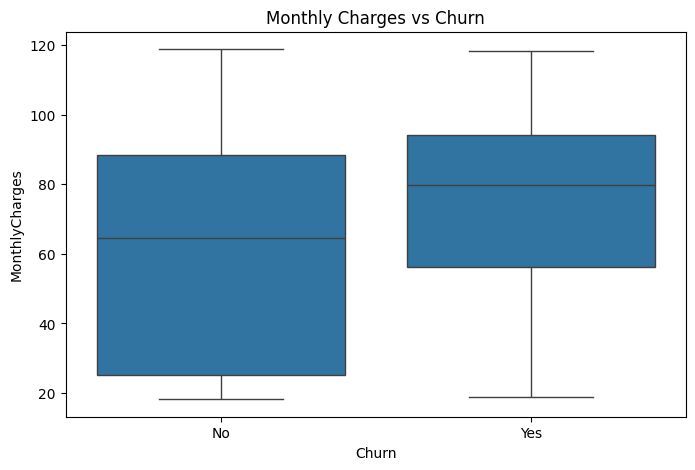

In [160]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Observation

Customers who churn generally tend to have higher monthly charges.

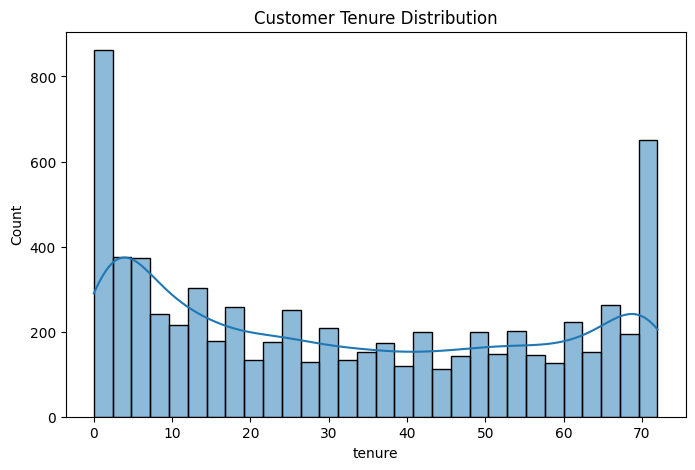

In [161]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

### Observation
Many customers have either recently joined or have remained with the company for a long period.

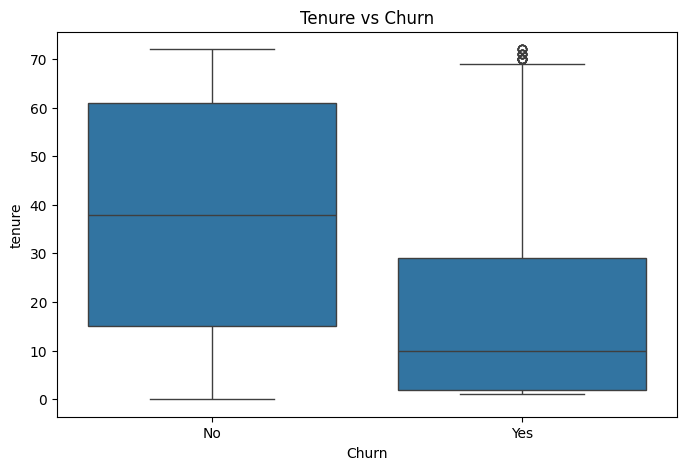

In [162]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

### Observation
Customers with shorter tenure are more likely to churn compared to long-term customers.

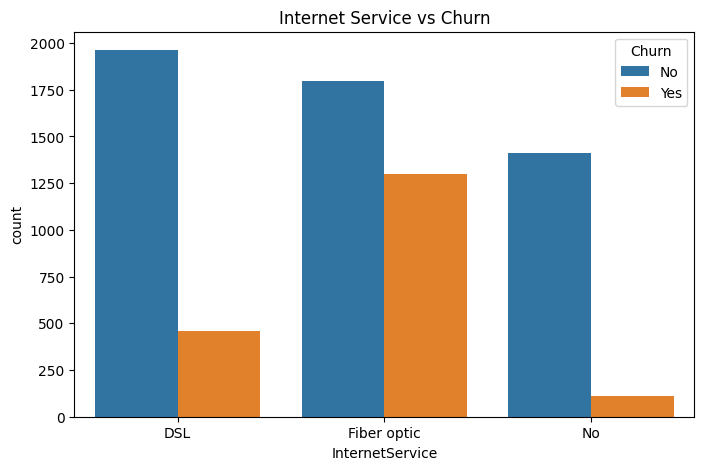

In [163]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

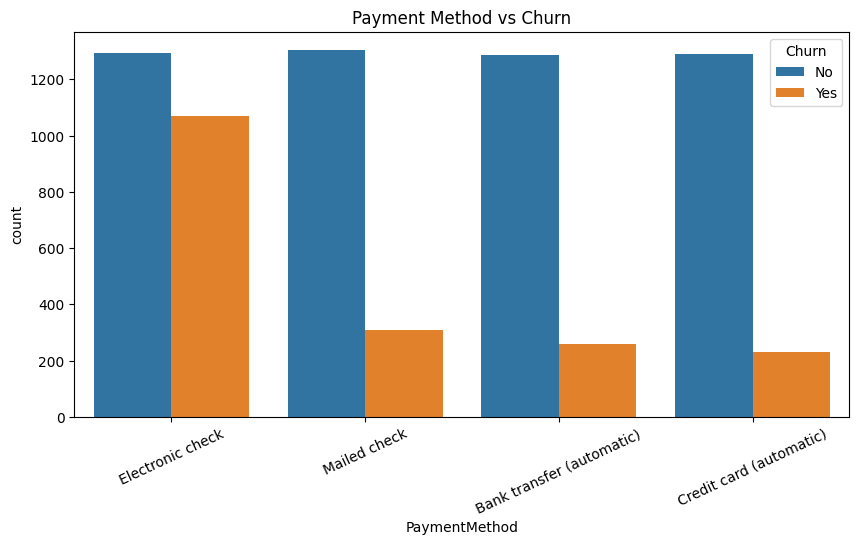

In [164]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=25)
plt.title("Payment Method vs Churn")
plt.show()

In [165]:
temp = df.copy()
le = LabelEncoder()

for col in temp.columns:
    if temp[col].dtype == 'object':
        temp[col] = le.fit_transform(temp[col])

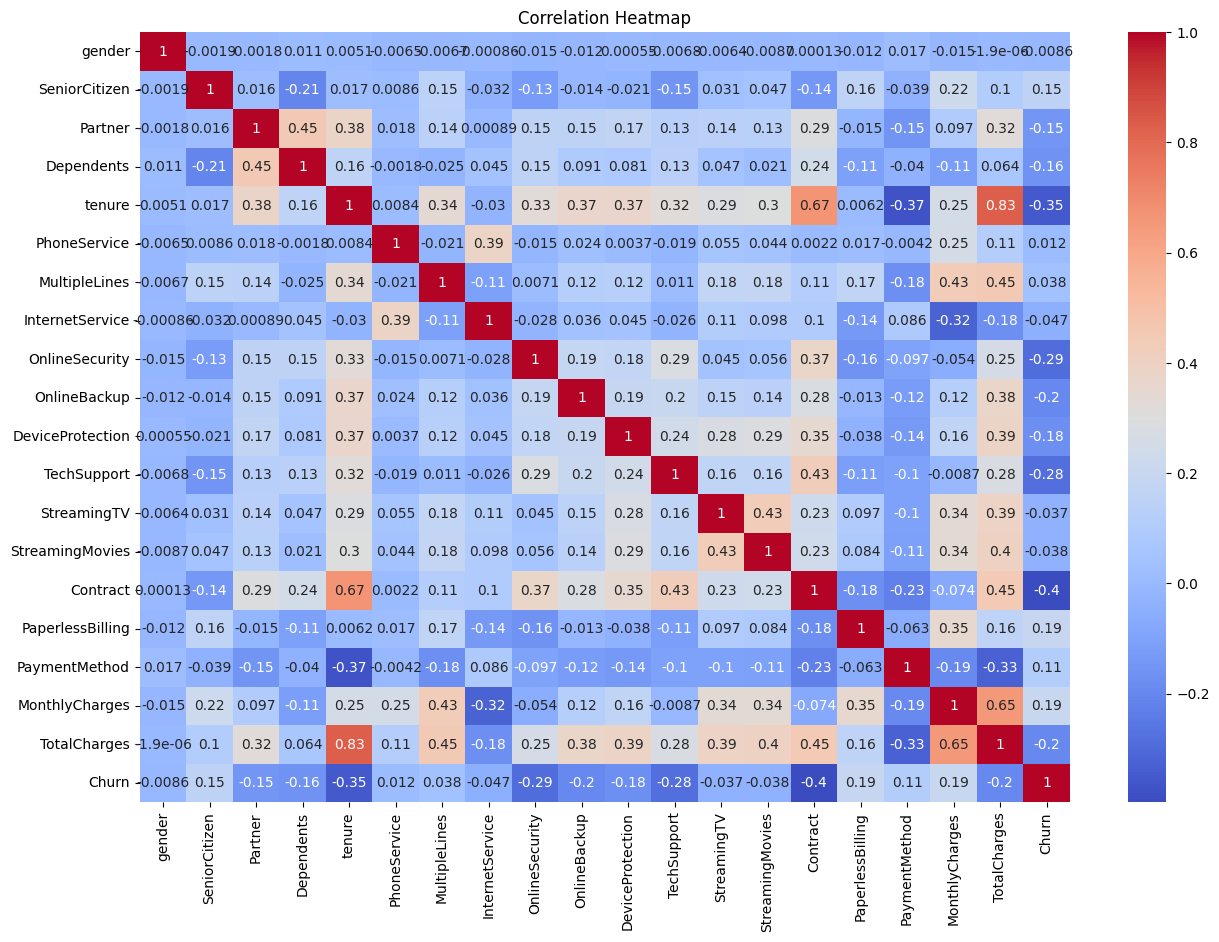

In [166]:
plt.figure(figsize=(15,10))
sns.heatmap(temp.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 4. Feature Encoding

Machine learning models cannot process categorical (text) data directly. Therefore, categorical variables are converted into numerical values using Label Encoding.

In [167]:
encoded_df = df.copy()

le = LabelEncoder()

for column in encoded_df.columns:
    if encoded_df[column].dtype == 'object':
        encoded_df[column] = le.fit_transform(encoded_df[column])

encoded_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [168]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


# 5. Feature Scaling

Feature scaling standardizes numerical values so that all features contribute equally during model training.

In [169]:
X = encoded_df.drop("Churn", axis=1)
y = encoded_df["Churn"]

In [170]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [171]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (5634, 19)
Testing Samples : (1409, 19)


# 6. Customer Segmentation using K-Means Clustering

K-Means groups customers into clusters based on similarities in their attributes.

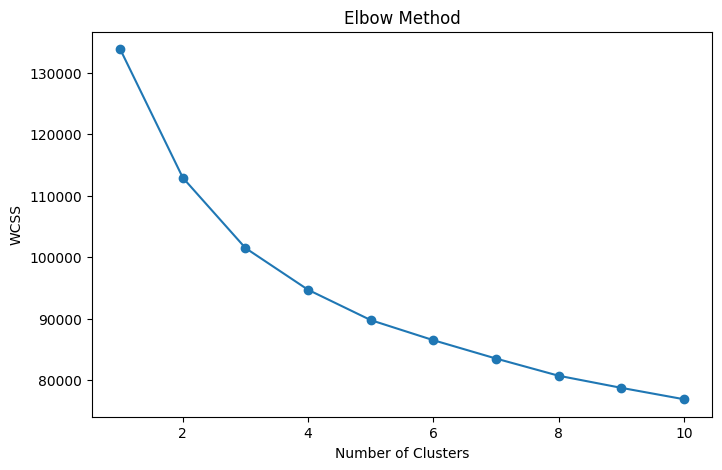

In [172]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [173]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)
encoded_df["Cluster"] = clusters

In [174]:
encoded_df["Cluster"].value_counts()

,count
Cluster,
2,2744
3,2091
1,1546
0,662


In [175]:
from sklearn.decomposition import PCA

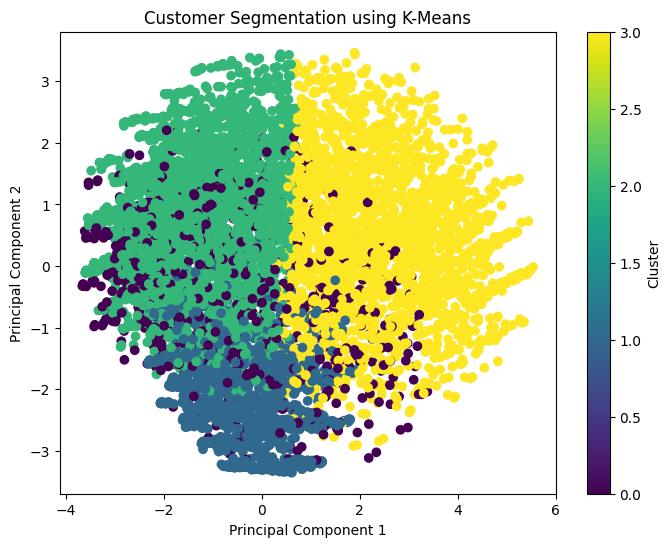

In [176]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

### Observation

The K-Means algorithm grouped customers into four distinct clusters based on similarities in their demographic and service-related attributes.

### Business Insight

Each customer segment can be targeted with personalized marketing campaigns, improving customer satisfaction and retention.

# 7. Customer Churn Prediction

This section builds three machine learning models to predict whether a customer is likely to churn.

Model 1: Logistic Regression

In [177]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [178]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))
print()
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
0.815471965933286

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



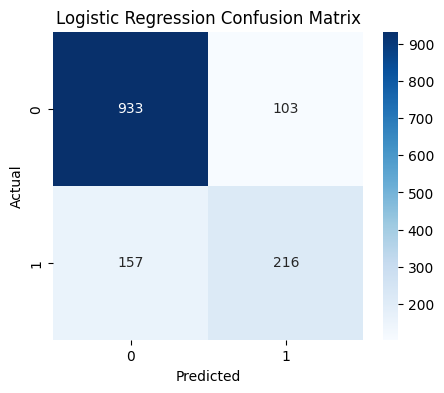

In [179]:
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model 2: Decision Tree

In [180]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [181]:
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))
print()

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy:
0.7246273953158269

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.49       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.73      1409



Model 3: Random Forest

In [182]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [183]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))
print()

print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
0.7970191625266146

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



### Comparing Models

In [184]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.815472
1,Decision Tree,0.724627
2,Random Forest,0.797019


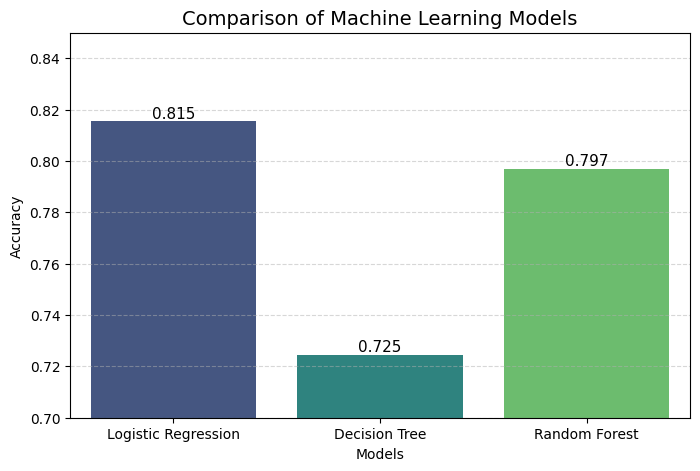

In [185]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=11)

plt.ylim(0.70, 0.85)

plt.title("Comparison of Machine Learning Models", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [186]:
best_model = results.loc[results["Accuracy"].idxmax(), "Model"]
best_accuracy = results["Accuracy"].max()

print(f"Best Model: {best_model}")
print(f"Accuracy: {best_accuracy:.4f}")

Best Model: Logistic Regression
Accuracy: 0.8155


### Observation

Among the three machine learning models evaluated, Logistic Regression achieved the highest accuracy on the test dataset. Random Forest performed slightly lower, while Decision Tree produced the lowest accuracy.

# Conclusion

This project successfully analyzed customer behavior using exploratory data analysis, segmented customers using K-Means clustering, and predicted customer churn using machine learning algorithms.

Among the evaluated models, Logistic Regression achieved the highest accuracy on this dataset, making it the most suitable model for churn prediction. The analysis also showed that customers with month-to-month contracts, shorter tenure, and higher monthly charges are more likely to churn.

These findings can help businesses identify customers at risk of leaving and implement targeted retention strategies such as personalized offers, loyalty programs, and long-term contract incentives.